In [1]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import ShuffleNetV2

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)

device = get_device()

model = ShuffleNetV2(num_classes=2, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [5]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "shufflenetv2_binary_target", 3)

Val Epoch 1: 100%|██████████| 264/264 [04:37<00:00,  1.05s/it, avg_acc=0.5820, avg_loss=0.6822]


Epoch 1/10 | ETA (Remaining): 04:33:27 | Total ETA: 05:03:50
  Train Loss: 0.6694 | Train Acc: 0.5923
  Val Loss: 0.6822 | Val Acc: 0.5820
  Val Precision: 0.5297
  Val Recall: 0.7436 | Val F1: 0.6187
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/shufflenetv2_binary_target.pt
------------------------------------------------------------


Val Epoch 2: 100%|██████████| 264/264 [04:38<00:00,  1.05s/it, avg_acc=0.6389, avg_loss=0.6441]


Epoch 2/10 | ETA (Remaining): 04:00:03 | Total ETA: 05:03:50
  Train Loss: 0.6529 | Train Acc: 0.6245
  Val Loss: 0.6441 | Val Acc: 0.6389
  Val Precision: 0.6227
  Val Recall: 0.5286 | Val F1: 0.5718
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Val Epoch 3: 100%|██████████| 264/264 [04:36<00:00,  1.05s/it, avg_acc=0.6407, avg_loss=0.6395]


Epoch 3/10 | ETA (Remaining): 03:31:10 | Total ETA: 05:03:50
  Train Loss: 0.6425 | Train Acc: 0.6387
  Val Loss: 0.6395 | Val Acc: 0.6407
  Val Precision: 0.6002
  Val Recall: 0.6354 | Val F1: 0.6173
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Val Epoch 4: 100%|██████████| 264/264 [04:33<00:00,  1.04s/it, avg_acc=0.6537, avg_loss=0.6332]


Epoch 4/10 | ETA (Remaining): 02:57:05 | Total ETA: 05:03:50
  Train Loss: 0.6360 | Train Acc: 0.6460
  Val Loss: 0.6332 | Val Acc: 0.6537
  Val Precision: 0.6439
  Val Recall: 0.5387 | Val F1: 0.5866
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 4 (patience 3 exceeded)


(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

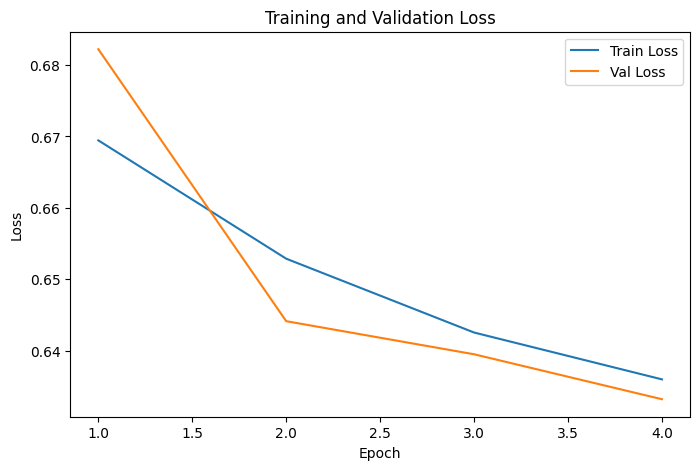

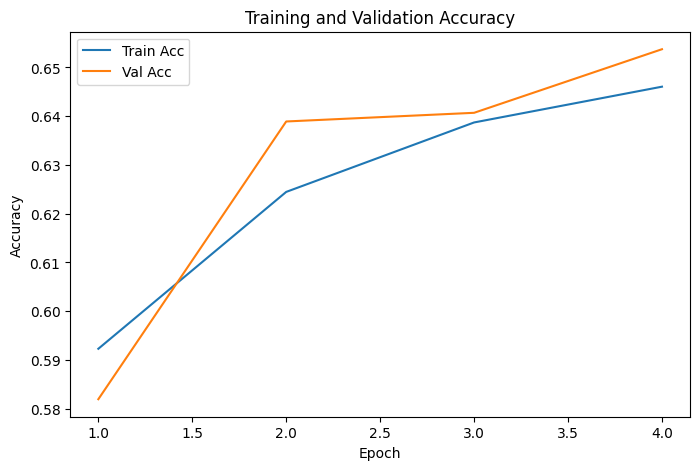

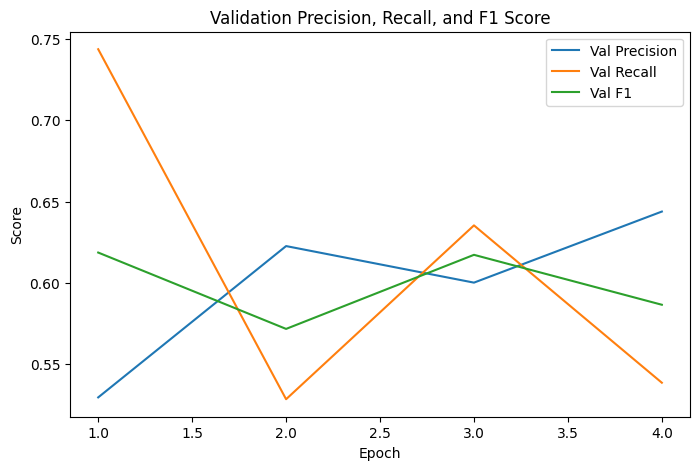

In [6]:
plot_training_history(history)

In [7]:
save_path = get_model_path("shufflenetv2_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = ShuffleNetV2(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/shufflenetv2_binary_target.pt


Val: 100%|██████████| 255/255 [04:30<00:00,  1.06s/it, avg_acc=0.5909, avg_loss=0.6763]


Test Results
  Loss: 0.6763
  Accuracy: 0.5909
  Precision: 0.5416
  Recall: 0.7462
  F1 Score: 0.6276


In [8]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"], "({:.2f}%)".format(result["probabilities"][result["predicted_class"]]*100))
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_004/images/00008051_016.png
Predicted class: abnormal (58.91%)
True label: normal
Probabilities: {'normal': 0.41085687279701233, 'abnormal': 0.5891430974006653}
